In [1]:
!pip install pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Advertising Analysis") \
    .getOrCreate()

sc = spark.sparkContext

In [2]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("Advertising.csv")

df.show(5)
df.printSchema()

+---+-----+-----+---------+-----+
|_c0|   TV|radio|newspaper|sales|
+---+-----+-----+---------+-----+
|  1|230.1| 37.8|     69.2| 22.1|
|  2| 44.5| 39.3|     45.1| 10.4|
|  3| 17.2| 45.9|     69.3|  9.3|
|  4|151.5| 41.3|     58.5| 18.5|
|  5|180.8| 10.8|     58.4| 12.9|
+---+-----+-----+---------+-----+
only showing top 5 rows

root
 |-- _c0: integer (nullable = true)
 |-- TV: double (nullable = true)
 |-- radio: double (nullable = true)
 |-- newspaper: double (nullable = true)
 |-- sales: double (nullable = true)



In [3]:
df_selected = df.select("TV", "radio", "newspaper", "sales")

In [4]:
from pyspark.sql.functions import col

df_transformed = df_selected.withColumn(
    "total_spend", col("TV") + col("radio") + col("newspaper")
)

In [5]:
df_transformed.show(5)

+-----+-----+---------+-----+------------------+
|   TV|radio|newspaper|sales|       total_spend|
+-----+-----+---------+-----+------------------+
|230.1| 37.8|     69.2| 22.1|337.09999999999997|
| 44.5| 39.3|     45.1| 10.4|             128.9|
| 17.2| 45.9|     69.3|  9.3|132.39999999999998|
|151.5| 41.3|     58.5| 18.5|             251.3|
|180.8| 10.8|     58.4| 12.9|250.00000000000003|
+-----+-----+---------+-----+------------------+
only showing top 5 rows



In [6]:
df_filtered = df_transformed.filter(col("total_spend") > 200)
df_filtered.show(5)

+-----+-----+---------+-----+------------------+
|   TV|radio|newspaper|sales|       total_spend|
+-----+-----+---------+-----+------------------+
|230.1| 37.8|     69.2| 22.1|337.09999999999997|
|151.5| 41.3|     58.5| 18.5|             251.3|
|180.8| 10.8|     58.4| 12.9|250.00000000000003|
|199.8|  2.6|     21.2| 10.6|             223.6|
|214.7| 24.0|      4.0| 17.4|             242.7|
+-----+-----+---------+-----+------------------+
only showing top 5 rows



In [7]:
df_grouped = df_filtered.groupBy().avg("sales", "total_spend")
df_grouped.show()

+------------------+-----------------+
|        avg(sales)| avg(total_spend)|
+------------------+-----------------+
|17.744117647058825|279.3460784313725|
+------------------+-----------------+



In [8]:
print("Total rows:", df.count())
print("Filtered rows:", df_filtered.count())

Total rows: 200
Filtered rows: 102


In [9]:
sample = df_filtered.take(5)
for row in sample:
    print(row)

Row(TV=230.1, radio=37.8, newspaper=69.2, sales=22.1, total_spend=337.09999999999997)
Row(TV=151.5, radio=41.3, newspaper=58.5, sales=18.5, total_spend=251.3)
Row(TV=180.8, radio=10.8, newspaper=58.4, sales=12.9, total_spend=250.00000000000003)
Row(TV=199.8, radio=2.6, newspaper=21.2, sales=10.6, total_spend=223.6)
Row(TV=214.7, radio=24.0, newspaper=4.0, sales=17.4, total_spend=242.7)


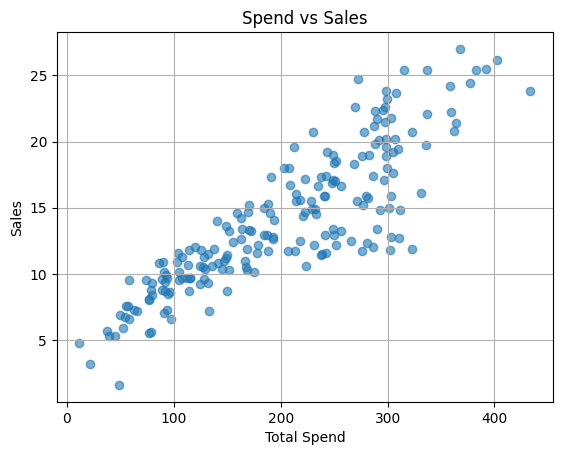

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to Pandas for plotting
pdf = df_transformed.toPandas()

plt.scatter(pdf["total_spend"], pdf["sales"], alpha=0.6)
plt.xlabel("Total Spend")
plt.ylabel("Sales")
plt.title("Spend vs Sales")
plt.grid(True)
plt.show()